In [88]:
from scripts.gtf_utils import parse_gene_map

import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import re

adata_dir = "anndata/pbmc_1k_v3.h5ad"
adata = sc.read_h5ad(adata_dir)
print(f"Loaded h5ad file from `{adata_dir}`")

Loaded h5ad file from `anndata/pbmc_1k_v3.h5ad`


In [89]:
print(adata)

AnnData object with n_obs × n_vars = 1153 × 36601
    obs: 'barcodes', 'sample'
    layers: 'unspliced'


In [90]:
print(f"Before filtering {adata.shape}")

# Filtering
sc.pp.filter_cells(adata, min_genes=200)  # removes droplets with little ambient RNA
sc.pp.filter_genes(adata, min_cells=3)    # removes uninformative genes 

print(f"After filtering {adata.shape}")

Before filtering (1153, 36601)
After filtering (1152, 17230)


In [91]:
# Log normalization
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

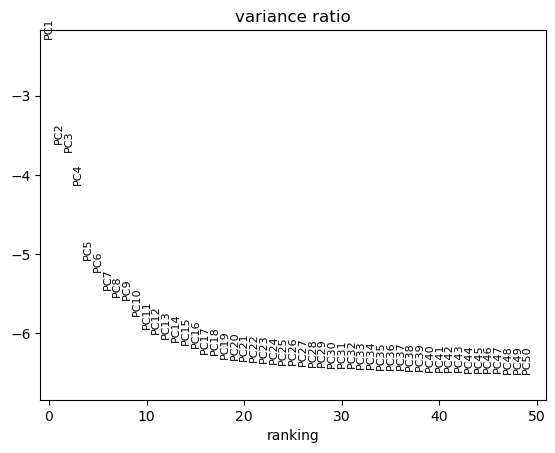

In [92]:
# Graphing PCA variance ratio for UMAP
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

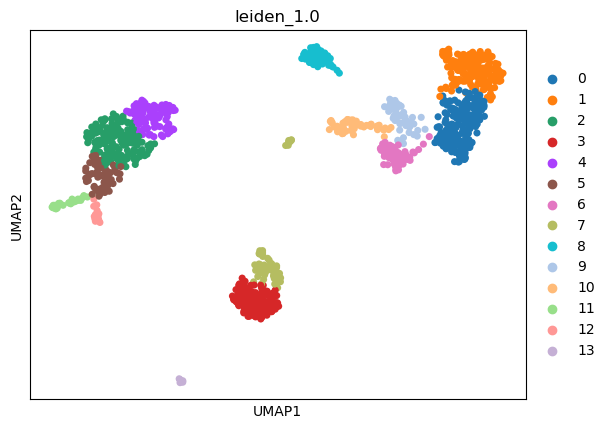

In [97]:
# Computing and plotting UMAP
sc.pp.neighbors(adata, n_pcs=15)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=1.0, key_added="leiden_1.0")

sc.pl.umap(adata, color="leiden_1.0")

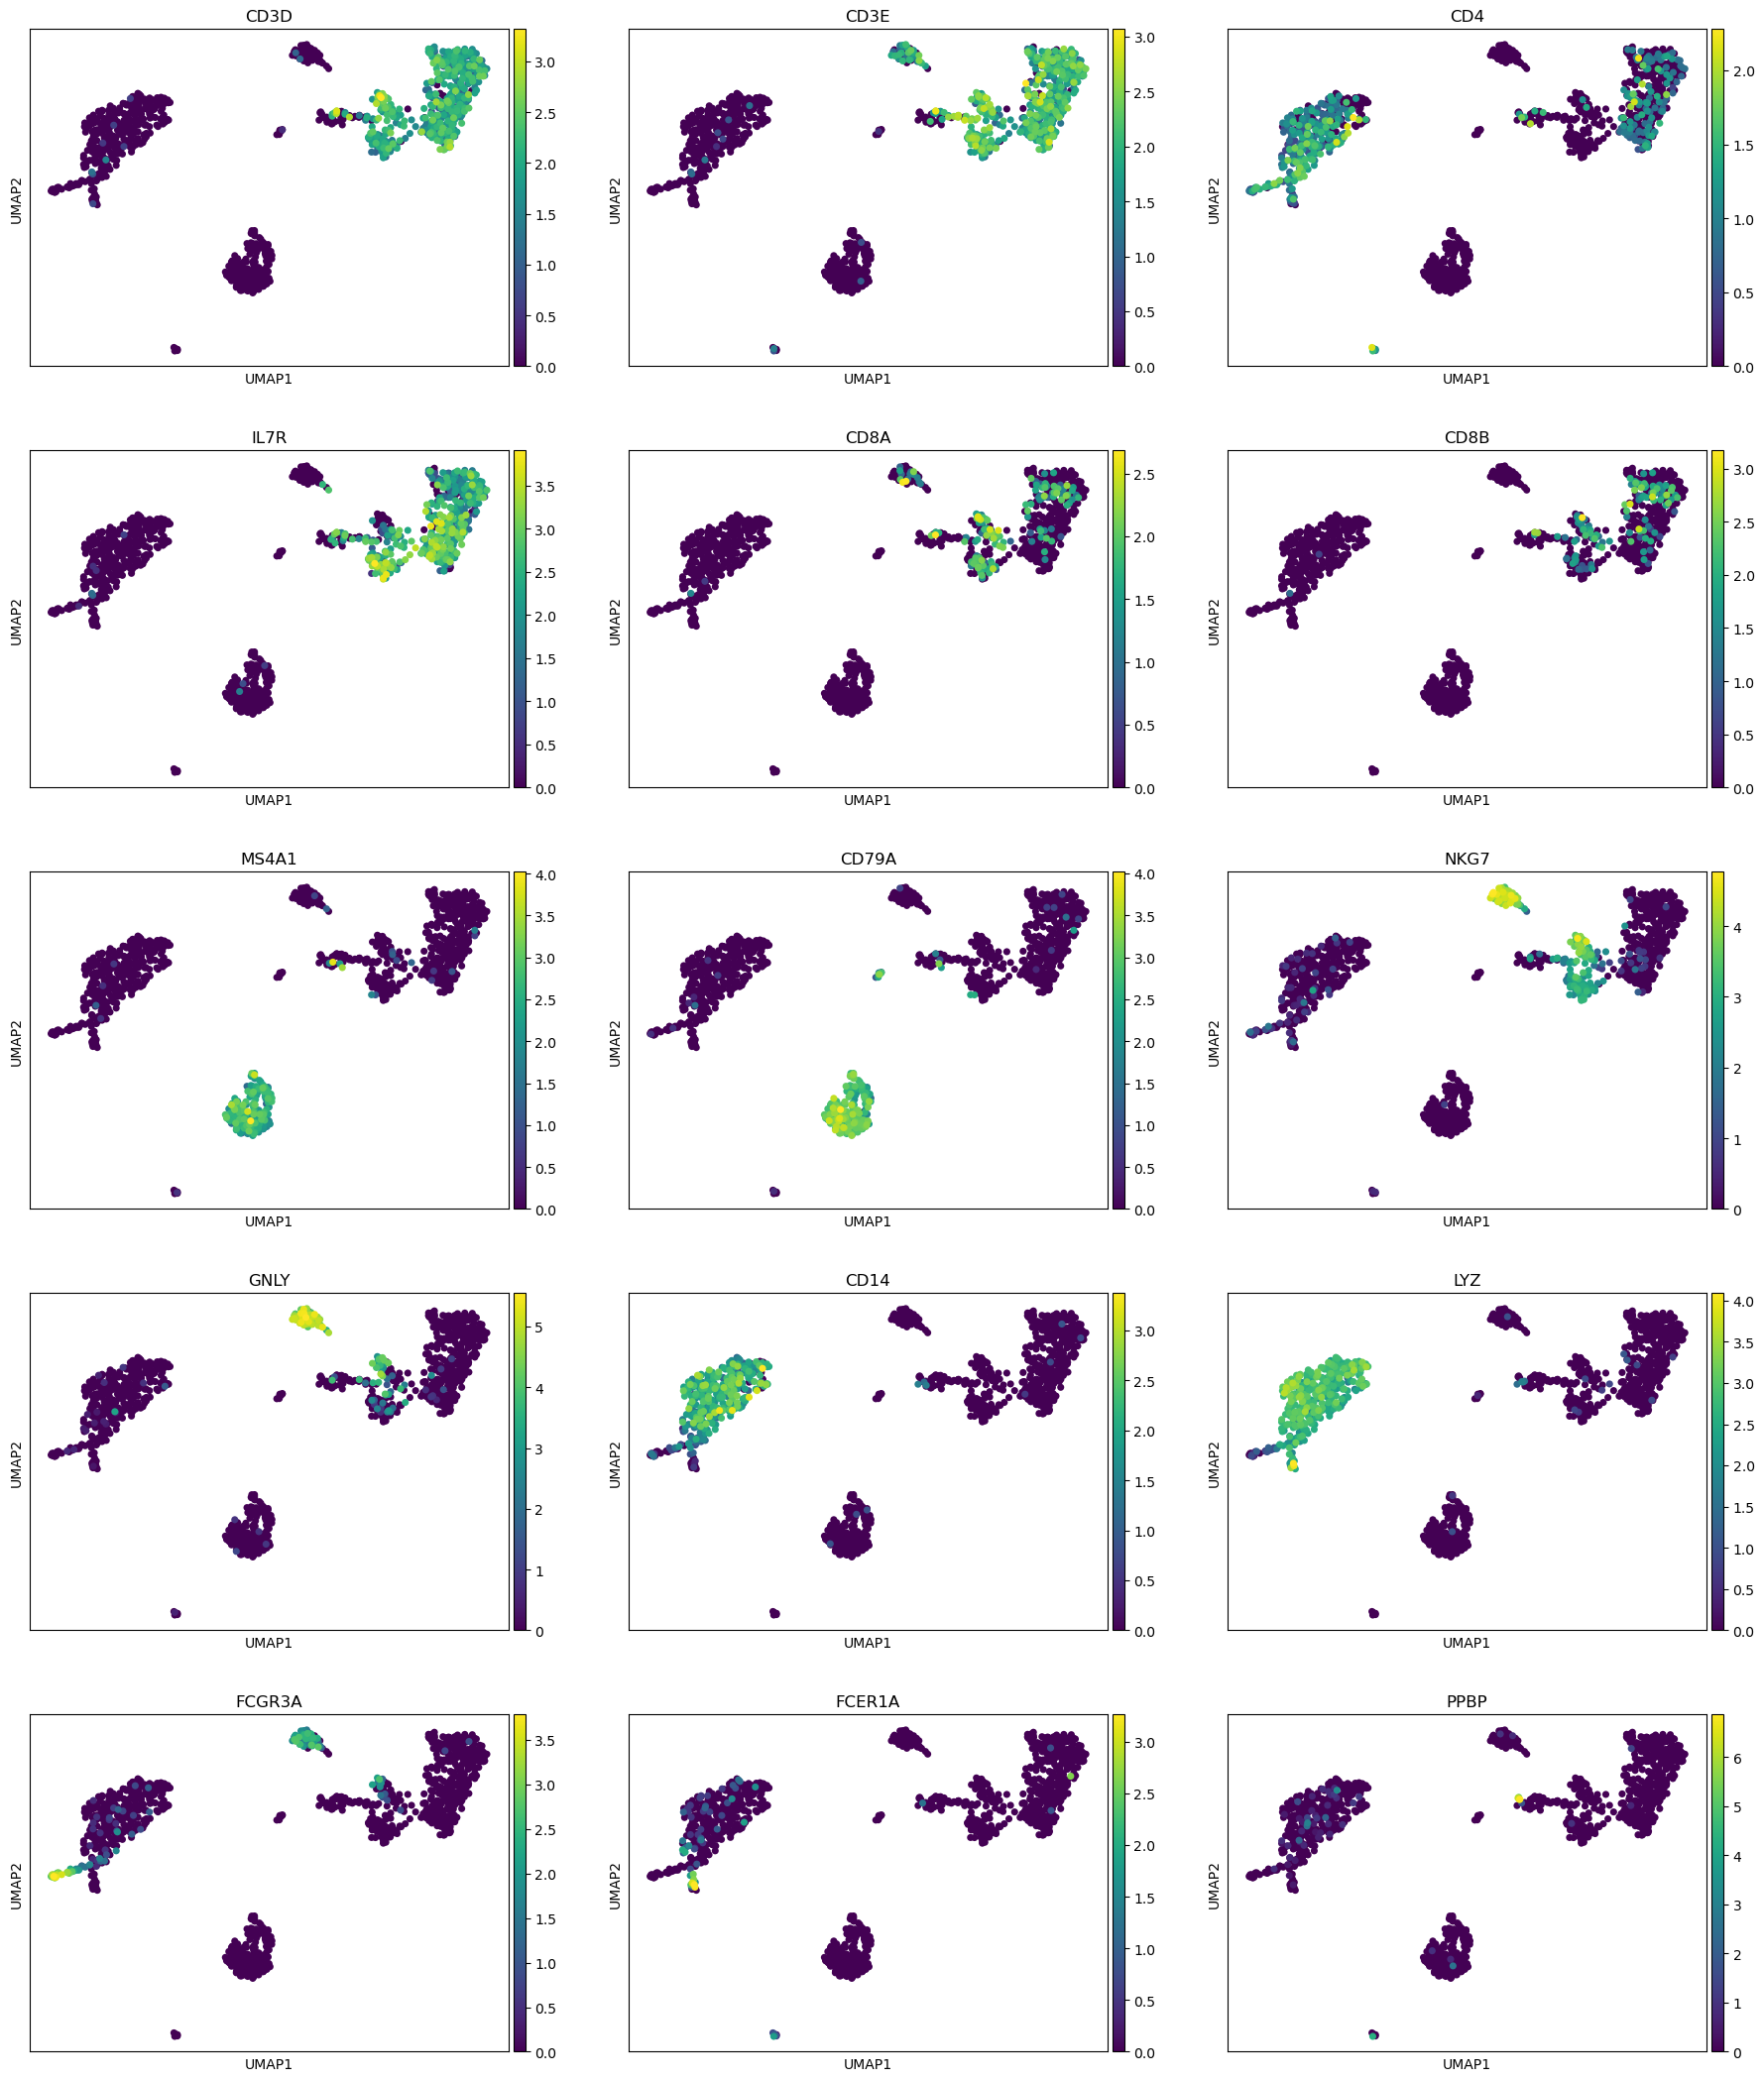

In [94]:
# Okay, lets take a look at these clusters
# First, map them to symbols (easier to work with):
gene_map = parse_gene_map("data/ref/genes.gtf")

bare_map = {re.sub(r"\.\d+$", "", k): v for k, v in gene_map.items()}
bare_ids = adata.var_names.str.replace(r"\.\d+$", "", regex=True)

adata.var["ensembl_id"] = adata.var_names
adata.var["gene_symbol"] = [bare_map.get(g, (g, ""))[0] for g in bare_ids]
adata.var_names = adata.var["gene_symbol"].values
adata.var_names_make_unique()

# Now create UMAPs for marker genes
pbmc_markers = {
    "T cells":       ["CD3D", "CD3E"],
    "CD4 T":         ["CD4", "IL7R"],
    "CD8 T":         ["CD8A", "CD8B"],
    "B cells":       ["MS4A1", "CD79A"],
    "NK cells":      ["NKG7", "GNLY"],
    "Monocytes":     ["CD14", "LYZ"],
    "FCGR3A+ Mono":  ["FCGR3A"],
    "Dendritic":     ["FCER1A"],
    "Platelets":     ["PPBP"],
}

genes = [g for gs in pbmc_markers.values() for g in gs if g in adata.var_names]

sc.pl.umap(adata, color=genes, ncols=3, cmap="viridis")

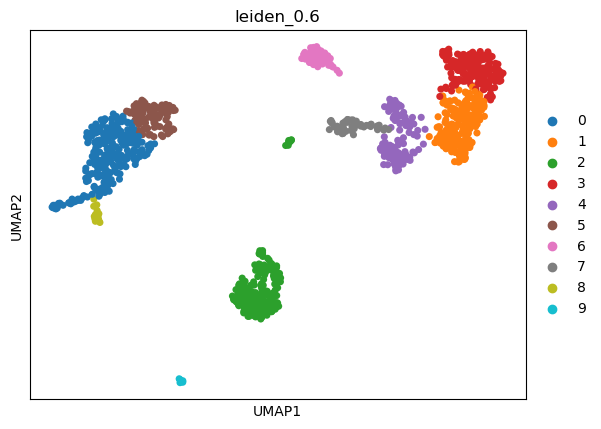

In [98]:
# Reduce UMAP resolution to match more closely to the groupings
sc.tl.leiden(adata, resolution=0.6, key_added="leiden_0.6")

sc.pl.umap(adata, color="leiden_0.6")

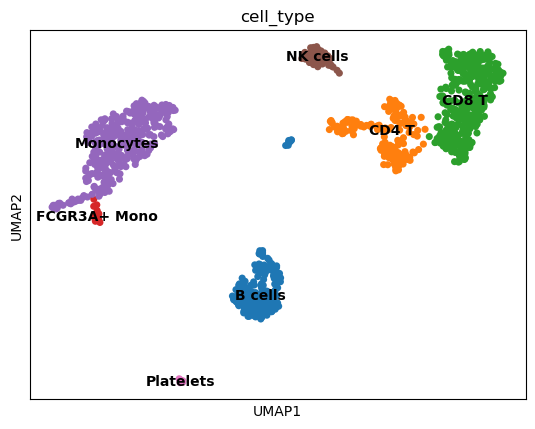

In [99]:
# Map UMAP clusters to defined cell types
cluster_names = {
    "0": "Monocytes",
    "1": "CD8 T",
    "2": "B cells",
    "3": "CD8 T",
    "4": "CD4 T",
    "5": "Monocytes",
    "6": "NK cells",
    "7": "CD4 T",
    "8": "FCGR3A+ Mono",
    "9": "Platelets"
}
adata.obs["cell_type"] = adata.obs["leiden_0.6"].map(cluster_names)
sc.pl.umap(adata, color="cell_type", legend_loc="on data")